# Flow compensation in a 2D gradient echo

A spoiled gradient echo excites a slice, encodes one line of k-space, and reads it out while the
readout gradient sweeps through the echo. The prephaser before the readout cancels the readout
lobe's area up to that instant, which puts $k = 0$ there — so a **stationary** spin arrives at the
echo with no phase from the readout axis. It is the workhorse acquisition for fast T1-weighted and
angiographic imaging.

That cancellation is a statement about the **zeroth** gradient moment only. The phase a spin
accumulates along one axis is

$$\phi = 2\pi \int G(t)\, x(t)\, \mathrm{d}t = 2\pi\left(m_0 x_0 + m_1 v\right),
\qquad m_n = \int G(t)\, (t - t_\text{echo})^n\, \mathrm{d}t$$

where $x_0$ is where the spin started and $v$ its velocity along that axis. Setting $m_0 = 0$
removes the first term. It says nothing about $m_1$, which is not zero, so a spin **moving** along
the axis arrives with a phase proportional to its velocity.

Flowing blood, CSF and a moving vessel wall all carry that term, and because it varies from shot
to shot with the flow it is not a constant phase that a magnitude image would hide. A
shot-to-shot phase variation along the phase-encode direction is one of the recognised
contributors to flow and motion artefact — ghosting, and signal loss where the velocity varies
within a voxel.

**This notebook is about the phase term, not about the image.** It measures $m_1$ on the emitted
waveform and shows it going to zero. Whether, and how much, that reduces artefact in a picture is
an image-level question needing a flow phantom or a scanner, and nothing here demonstrates it.

**Flow compensation**, or gradient moment nulling, removes it by reshaping the gradients so that
$m_1 = 0$ at the echo as well as $m_0$. On the readout axis the canonical construction uses three
lobes before the echo rather than two:

```text
ordinary        [ winder ] [ readout ->  echo         m0 = 0, m1 != 0
compensated  [ w1 ][ w2 ] [ readout ->  echo          m0 = 0, m1 = 0
```

This notebook builds both, measures the moments on the emitted waveform, and shows what the
compensation costs in echo time.

This is the third notebook of the 2D gradient-echo family: [`01_build`](01_build.ipynb) builds the
sequence and [`02_simulate_and_reconstruct`](02_simulate_and_reconstruct.ipynb) images with it.
Flow compensation is a physical capability you add to that sequence, not a different one.

| | |
|---|---|
| **1** | the first moment of an ordinary gradient echo |
| **2** | asking for flow compensation |
| **3** | measuring it on the emitted repetition |
| **4** | every axis, and what each one costs |
| **5** | the files |

**Output:** two `.seq` files, an ordinary gradient echo and a flow-compensated one.
**Needs nothing but `seqcraft`.**

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM, MATRIX, THICKNESS_MM = 220.0, 64, 5.0
BANDWIDTH_HZ_PX = 500.0
SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 1. The first moment of an ordinary gradient echo

`GRE2DTR` is one repetition: excitation, phase encode, readout, spoiler. Its moments are a
property of the waveform it emits, so the way to read them is to integrate the events themselves
between the excitation and the echo.

In [2]:
def moment(shot, order, axis, kernel):
    """
    The order-th gradient moment on one axis, from the excitation to the echo.

    Integrated from the excitation instant rather than from the start of the repetition. On x
    and y the two agree, because nothing plays there earlier. On z they do not: half the slice
    selection lobe plays before the RF centre, and it dephases nothing, because there is no
    transverse magnetisation yet.
    """
    origin, echo = kernel.exc.time_to_center(), kernel.time_to_echo()
    total = 0.0
    for start, event, _ in sc.flatten(shot):
        if getattr(event, 'type', None) not in ('trap', 'grad'):
            continue
        if getattr(event, 'channel', None) != axis:
            continue
        times, amps = sc.events.knots_of(event, start)
        if times.size < 2 or echo <= times[0]:
            continue
        if times[-1] <= origin:                    # entirely before there is anything to dephase
            continue
        if times[0] < origin:                      # a lobe straddling the excitation instant
            cut = int(np.searchsorted(times, origin))
            edge = float(np.interp(origin, times, amps))
            times = np.concatenate(([origin], times[cut:]))
            amps = np.concatenate(([edge], amps[cut:]))
        if echo < times[-1]:                       # the readout lobe straddles the echo
            cut = int(np.searchsorted(times, echo))
            edge = float(np.interp(echo, times, amps))
            times, amps = np.append(times[:cut], echo), np.append(amps[:cut], edge)
        total += sc.events.pwl_moment(times - origin, amps, order)
    return float(total)


ordinary = sc.modules.GRE2DTR(opts=opts, fov_mm=FOV_MM, matrix=(MATRIX, MATRIX),
                              thickness_mm=THICKNESS_MM, flip_deg=20.0,
                              bandwidth_hz_px=BANDWIDTH_HZ_PX)
shot = ordinary(line=MATRIX // 2)

print(f'an ordinary gradient echo, TE = {ordinary.te_s * 1e3:.3f} ms\n')
print(f'   m0 on x at the echo   {moment(shot, 0, "x", ordinary):+12.3e}  1/m')
print(f'   m1 on x at the echo   {moment(shot, 1, "x", ordinary):+12.3e}  s/m')

v = 0.5
turns = moment(shot, 1, 'x', ordinary) * v
print(f'\na spin moving at {v} m/s along x therefore arrives with {turns:+.2f} turns '
      f'({turns * 2:+.2f} pi) of phase')

an ordinary gradient echo, TE = 3.114 ms

   m0 on x at the echo     -5.684e-14  1/m
   m1 on x at the echo     +1.184e-01  s/m

a spin moving at 0.5 m/s along x therefore arrives with +0.06 turns (+0.12 pi) of phase


`m0` is at the arithmetic floor — that is what the prephaser is for, and it is why a stationary
spin is unaffected. `m1` is not, and half a metre per second is an ordinary velocity in the aorta
or the carotid.

The phase itself would be harmless if it were constant — a magnitude image would not show it. What
makes it matter is that it is proportional to velocity, so it differs between shots as the flow
pulses, and a shot-to-shot phase variation along the phase-encode direction is the mechanism
behind flow ghosting. The artefact is downstream of this number; what follows measures the
number.

---

## 2. Asking for flow compensation

The requirement is physical — *no first moment at the echo, on this axis* — so that is what you
say. Which part of the repetition has to change to deliver it is the repetition's problem.

In [3]:
compensated = sc.modules.GRE2DTR(opts=opts, fov_mm=FOV_MM, matrix=(MATRIX, MATRIX),
                                 thickness_mm=THICKNESS_MM, flip_deg=20.0,
                                 bandwidth_hz_px=BANDWIDTH_HZ_PX,
                                 flow_comp=sc.FlowCompensation(axis='x'))

print(f'{"":>14}{"prephaser lobes":>18}{"areas / (1/m)":>30}{"total":>12}')
for name, kernel in (('ordinary', ordinary), ('compensated', compensated)):
    areas = [float(lobe.area) for lobe in kernel.ro.prephaser_lobes]
    written = '  '.join(f'{a:+9.2f}' for a in areas)
    print(f'{name:>14}{len(areas):18d}{written:>30}{sum(areas):+12.2f}')

                 prephaser lobes                 areas / (1/m)       total
      ordinary                 1                       -149.91     -149.91
   compensated                 2            +233.70    -383.62     -149.91


The compensated winder is two lobes of opposite sign rather than one, and their areas still sum to
the same total — the echo condition is not traded away to get the first moment. Two lobes give two
degrees of freedom, and two moments to null need exactly two.

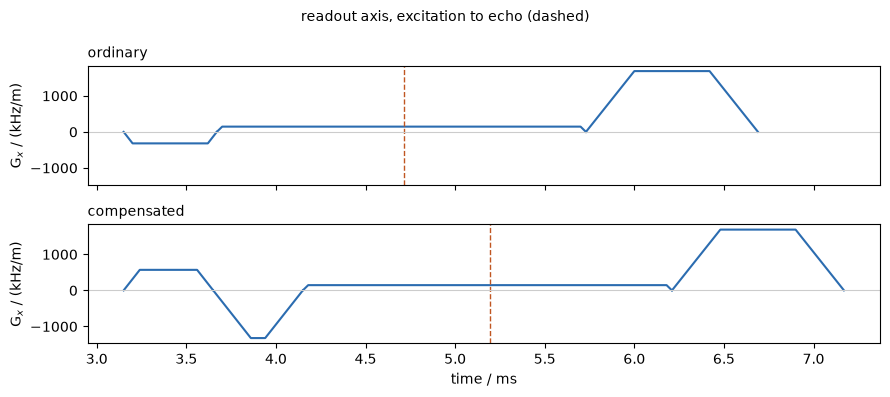

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9.0, 4.0), sharex=True, sharey=True)
for ax, (name, kernel) in zip(axes, (('ordinary', ordinary), ('compensated', compensated))):
    for start, event, _ in sc.flatten(kernel(line=MATRIX // 2)):
        if getattr(event, 'channel', None) != 'x':
            continue
        times, amps = sc.events.knots_of(event, start)
        ax.plot(times * 1e3, np.asarray(amps) / 1e3, color='#2b6cb0')
    ax.axvline(kernel.time_to_echo() * 1e3, color='#c05621', ls='--', lw=1.0)
    ax.axhline(0.0, color='0.8', lw=0.8)
    ax.set_ylabel('G$_x$ / (kHz/m)')
    ax.set_title(name, loc='left', fontsize=10)
axes[-1].set_xlabel('time / ms')
fig.suptitle('readout axis, excitation to echo (dashed)', fontsize=10)
fig.tight_layout()
plt.show()

---

## 3. Measuring it on the emitted repetition

The moments below are integrated over every gradient the repetition plays on that axis, not over
the prephaser alone, and across three protocols with different readout durations.

In [5]:
print(f'{"bandwidth":>12}{"matrix":>8}{"moment":>12}{"ordinary":>14}{"compensated":>14}')
for bw, n in ((300.0, 64), (500.0, 64), (900.0, 128)):
    made = {}
    for name, extra in (('ordinary', {}),
                        ('compensated', {'flow_comp': sc.FlowCompensation(axis='x')})):
        made[name] = sc.modules.GRE2DTR(opts=opts, fov_mm=FOV_MM, matrix=(n, n),
                                        thickness_mm=THICKNESS_MM, flip_deg=20.0,
                                        bandwidth_hz_px=bw, **extra)
    for order, unit in ((0, '1/m'), (1, 's/m')):
        values = {k: moment(v(line=n // 2), order, 'x', v) for k, v in made.items()}
        print(f'{bw:12.0f}{n:8d}{f"m{order} / {unit}":>12}'
              f'{values["ordinary"]:+14.3e}{values["compensated"]:+14.3e}')

   bandwidth  matrix      moment      ordinary   compensated
         300      64    m0 / 1/m    +0.000e+00    -7.390e-13
         300      64    m1 / s/m    +1.667e-01    -1.665e-15
         500      64    m0 / 1/m    -5.684e-14    -4.832e-13
         500      64    m1 / s/m    +1.184e-01    -1.055e-15
         900     128    m0 / 1/m    +3.979e-13    -2.274e-13
         900     128    m1 / s/m    +1.924e-01    -2.220e-16


`m0` stays at the floor in both columns across every protocol — the echo is still where it should
be — and `m1` drops from something a moving spin can feel to the same floor.

---

## 4. What it costs, and on which axis

Three lobes before the echo take longer than two, so the echo moves later.

In [6]:
print(f'{"":>14}{"winder / ms":>14}{"TE / ms":>10}{"TR / ms":>10}')
for name, kernel in (('ordinary', ordinary), ('compensated', compensated)):
    print(f'{name:>14}{kernel.winder_s * 1e3:14.3f}{kernel.te_s * 1e3:10.3f}'
          f'{kernel.tr_s * 1e3:10.3f}')
print(f'\nthe echo moves out by {(compensated.te_s - ordinary.te_s) * 1e3:.3f} ms')

                 winder / ms   TE / ms   TR / ms
      ordinary         0.520     3.114     6.690
   compensated         1.000     3.594     7.210



the echo moves out by 0.480 ms


A later echo means more T2\* decay and more time for off-resonance to accumulate, which is the
trade every flow-compensated protocol makes.

Flow compensation is per axis, and a repetition can carry it on more than one. Which axes are
available depends on the sequence: this one owns the phase-encode winder and the readout
prephaser, while its z gradient is the slice rephaser that the excitation realises for itself.

In [7]:
for axis in ('x', 'y', 'z', ('x', 'y'), ('x', 'y', 'z')):
    kernel = sc.modules.GRE2DTR(opts=opts, fov_mm=FOV_MM, matrix=(MATRIX, MATRIX),
                                thickness_mm=THICKNESS_MM, flip_deg=20.0,
                                bandwidth_hz_px=BANDWIDTH_HZ_PX,
                                flow_comp=sc.FlowCompensation(axis=axis))
    named = (axis,) if isinstance(axis, str) else axis
    shot = kernel(line=MATRIX // 4)
    got = '  '.join(f'm1({a}) = {moment(shot, 1, a, kernel):+9.2e}' for a in named)
    print(f'axis={axis!r:16} TE {kernel.te_s * 1e3:6.3f} ms   {got}')

axis='x'              TE  3.594 ms   m1(x) = -1.05e-15
axis='y'              TE  3.764 ms   m1(y) = +6.66e-16


axis='z'              TE  4.144 ms   m1(z) = +2.22e-15


axis=('x', 'y')       TE  3.774 ms   m1(x) = -7.77e-16  m1(y) = +6.66e-16
axis=('x', 'y', 'z')  TE  4.154 ms   m1(x) = +3.33e-16  m1(y) = +1.11e-16  m1(z) = +2.22e-15


Three axes, one spelling, and three different parts of the repetition doing the work:

```text
x    the readout's own prephaser, reshaped into two lobes
y    the phase-encode winder, designed together with the encode area that shares it
z    the slice rephasing, which the repetition takes over from the excitation
```

**Which of those happens is an implementation detail.** A caller asks for the physics and the
repetition decides who owns the problem; nothing above has to know that `x` is solved in closed
form by one component while `y` and `z` are designed jointly with everything else in that window.

Compensating several axes together costs more echo time than any one alone, because their winders
share an interval and the longest sets it. `z` is the expensive one here: the slice lobe carries a
large zeroth moment far from the echo, so cancelling its first moment takes real area.

Nulling `m1` on `z` must not be bought by leaving `k_z` somewhere other than zero — the rephasing
and the compensation are one problem on that axis, and the repetition solves both:

In [8]:
slice_comp = sc.modules.GRE2DTR(opts=opts, fov_mm=FOV_MM, matrix=(MATRIX, MATRIX),
                                thickness_mm=THICKNESS_MM, flip_deg=20.0,
                                bandwidth_hz_px=BANDWIDTH_HZ_PX,
                                flow_comp=sc.FlowCompensation(axis='z'))

print(f'{"":>14}{"m0 on z / (1/m)":>18}{"m1 on z / (s/m)":>18}{"TE / ms":>10}')
for name, kernel in (('ordinary', ordinary), ('compensated', slice_comp)):
    shot = kernel(line=MATRIX // 4)
    print(f'{name:>14}{moment(shot, 0, "z", kernel):18.3e}'
          f'{moment(shot, 1, "z", kernel):18.3e}{kernel.te_s * 1e3:10.3f}')

                 m0 on z / (1/m)   m1 on z / (s/m)   TE / ms

      ordinary         1.137e-13        -4.260e-01     3.114
   compensated         4.547e-13         2.220e-15     4.144


---

## 5. The files

Two sequences: the ordinary gradient echo, and the **fully** compensated one — `x`, `y` and `z`
together, which is what a flow-compensated protocol would actually run. The single-axis cases
above are there to show where each one is solved, not to be shipped separately.

In [9]:
fully = sc.modules.GRE2DTR(opts=opts, fov_mm=FOV_MM, matrix=(MATRIX, MATRIX),
                           thickness_mm=THICKNESS_MM, flip_deg=20.0,
                           bandwidth_hz_px=BANDWIDTH_HZ_PX,
                           flow_comp=sc.FlowCompensation(axis=('x', 'y', 'z')))

print(f'{"":>14}{"blocks":>9}{"duration / s":>14}   file')
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', sc.SeqCraftWarning)
    for name, kernel in (('ordinary', ordinary), ('compensated', fully)):
        scan = sc.LogicBlock('gre_2d_flow_comp')
        for line in range(MATRIX):
            scan.add(line * kernel.tr_s, kernel(line=line, phase_deg=117.0 * line))
        seq = sc.compile(scan, opts)
        path = SEQ_DIR / f'gre_2d_flow_comp_{name}.seq'
        seq.write(str(path))
        print(f'{name:>14}{len(seq.block_events):9d}{seq.duration()[0]:14.3f}   {path}')

for warning in caught:
    print(f'\n{warning.message}')

                 blocks  duration / s   file


      ordinary      256         0.428   seq/gre_2d_flow_comp_ordinary.seq


   compensated      256         0.532   seq/gre_2d_flow_comp_compensated.seq

192 blocks over the vector-norm limit (legal on real amplifiers): gre_2d_flow_comp.GRE2DTR.CartesianLine, gre_2d_flow_comp.GRE2DTR.Excitation, gre_2d_flow_comp.GRE2DTR.PhaseEncode (slew 168% at 3.150 ms), gre_2d_flow_comp.GRE2DTR.PhaseEncode, gre_2d_flow_comp.GRE2DTR.spoiler (grad 142% at 5.730 ms), gre_2d_flow_comp.GRE2DTR.PhaseEncode, gre_2d_flow_comp.GRE2DTR.spoiler (slew 169% at 5.730 ms), gre_2d_flow_comp.GRE2DTR.CartesianLine, gre_2d_flow_comp.GRE2DTR.Excitation, gre_2d_flow_comp.GRE2DTR.PhaseEncode (slew 166% at 9.840 ms), gre_2d_flow_comp.GRE2DTR.PhaseEncode, gre_2d_flow_comp.GRE2DTR.spoiler (grad 142% at 12.420 ms) (+187 more sites)

191 same-axis gradient merges: gre_2d_flow_comp.GRE2DTR.joint.joint (axis z) x64, gre_2d_flow_comp.GRE2DTR.CartesianLine (axis x) x64, gre_2d_flow_comp.GRE2DTR.joint (axis y) x63

256 blocks over the vector-norm limit (legal on real amplifiers): gre_2d_flow_comp.GRE2DTR.

---

## Summary

A gradient echo cancels the readout gradient's zeroth moment at the echo, which puts $k = 0$
there and leaves a stationary spin unaffected. The first moment is not zero, so a spin moving
along that axis arrives with a phase $2\pi m_1 v$ — and because the flow pulses, that phase differs
between shots, which is the mechanism behind flow ghosting and flow-related signal loss.

Flow compensation nulls $m_1$ as well, by splitting the prephaser into two lobes of opposite sign
whose areas still sum to the same total. Measured on the emitted repetition across three
protocols, $m_1$ on the readout axis falls to the arithmetic floor while $m_0$ stays there. The
cost is a later echo, because three lobes before it take longer than two.

**What this notebook does not cover.** Above all, **image-level artefact reduction is not
demonstrated here.** What is demonstrated is that the velocity-dependent phase term goes to zero:
`m1 = 0` on the emitted waveform, measured across three protocols. How much artefact that removes
in a real acquisition depends on the flow, the protocol and the rest of the sequence, and
establishing it needs a flow phantom or a scanner.

Compensation is also applied at the first echo only; later echoes of a multi-echo train accumulate
their own first moment from the lobes between them. Nulling the second
moment — acceleration — needs a further lobe and is not implemented. And flow compensation removes
the velocity phase rather than measuring it: to *measure* velocity you deliberately create a known
first-moment difference between two acquisitions, which is phase contrast, in
[`pc_gre_2d/`](../pc_gre_2d/).

## References

Bernstein, King and Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004 — §9.2 covers gradient
moment nulling, including the two-lobe construction used here and the extension to higher moments.

Pattany et al., *Motion artifact suppression technique (MAST) for MR imaging*, J Comput Assist
Tomogr 11(3):369-377, 1987 — the original description of first-moment nulling for artefact
suppression.